# Toy 1D Regression: SVD Optimizer Analysis (Full Scan, 10 seeds)

Reproduces the 'Custom plots' section of `toy_1d_analysis.ipynb` but averages over 10 model seeds per config, showing mean curves with ±1 std bands. Best configs selected by lowest *mean* final val loss.

## 1. Setup & Data Loading

In [36]:
%load_ext autoreload
%autoreload 2

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from pathlib import Path
import warnings
import re
warnings.filterwarnings('ignore')

from style import set_style, lr_labels, load_results, average_over_seeds
set_style()

PLOT_DIR = Path('plots/toy_1d_fullscan')
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Plots will be saved to: {PLOT_DIR.resolve()}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Plots will be saved to: /Users/sambt/iaifi/sv3/analysis/plots/toy_1d_fullscan


In [42]:
df = load_results("toy_1d_scan")

print(f"Total: {len(df)} runs, optimizers: {sorted(df['optimizer'].unique())}")
print(f"Model seeds: {sorted(df['model_seed'].unique())}")
print(f"Batch sizes: {sorted(df['batch_size'].unique())}")

Loaded 1330 runs from ../experiment_results/toy_1d_scan/ (directory format)
Total: 1330 runs, optimizers: ['Adam', 'LBFGS', 'PolyakSGD', 'RMSprop', 'SGD', 'SVD']
Model seeds: [np.int64(4310), np.int64(4311), np.int64(4312), np.int64(4313), np.int64(4314), np.int64(4315), np.int64(4316), np.int64(4317), np.int64(4318), np.int64(4319)]
Batch sizes: [np.int64(32)]


In [43]:
# Remove incomplete LBFGS runs (NaN at end of val curve)
def is_bad(row):
    if row['optimizer'] == 'LBFGS' and np.isnan(row['losses']['val'][-1]):
        return True
    return False
df = df[~df.apply(is_bad, axis=1)].reset_index(drop=True)
print(f"After removing bad LBFGS runs: {len(df)}")

After removing bad LBFGS runs: 1184


In [44]:
# Make a run ID to group by which doesn't include the model seed

def remove_mseed(run_id):
    return re.sub(r'_mseed\d+', '', run_id)
df['run_id_base'] = df.apply(lambda row: remove_mseed(row['run_id']), axis=1)

In [51]:
df.columns

Index(['run_id', 'optimizer', 'batch_size', 'k_fraction', 'k', 'lr', 'rtol',
       'weight_decay', 'model_seed', 'loader_seed', 'svd_mode', 'svd_info',
       'losses', 'mlp_width', 'lbfgs_max_iter', 'lbfgs_history_size',
       'lbfgs_line_search_fn', 'polyak_f_star', 'polyak_max_lr', 'polyak_eps',
       'rmsProp', 'alpha_rmsProp', 'microbatch_size', 'param_fraction',
       'variable_k', 'kappa', 'run_id_base'],
      dtype='object')

In [58]:
to_keep = ['run_id_base', 'optimizer', 'batch_size', 'kappa', 'k_fraction','k',
           'lr','rtol','weight_decay','svd_mode','loader_seed','mlp_width','lbfgs_max_iter','lbfgs_line_search_fn','lbfgs_history_size',
           'polyak_f_star','polyak_max_lr','polyak_eps','rmsProp','alpha_rmsProp','microbatch_size','param_fraction','variable_k']
df_mean = {n:[] for n in to_keep}
df_mean['train_loss_mean'] = []
df_mean['val_loss_mean'] = []
df_mean['train_loss_std'] = []
df_mean['val_loss_std'] = []

df_svd = {}
for name, block in df.groupby('run_id_base'):
    for t in to_keep:
        df_mean[t].append(block[t].iloc[0])
    train_losses = np.array([r['losses']['train'] for _, r in block.iterrows()])
    val_losses = np.array([r['losses']['val'] for _, r in block.iterrows()])
    df_mean['train_loss_mean'].append(np.mean(train_losses,axis=0))
    df_mean['val_loss_mean'].append(np.mean(val_losses,axis=0))
    df_mean['train_loss_std'].append(np.std(train_losses,axis=0))
    df_mean['val_loss_std'].append(np.std(val_losses,axis=0))
df_mean = pd.DataFrame(df_mean)

In [59]:
# Per-run derived scalars (averaged over seeds downstream)
def get_final_loss(row, loss_type='val'):
    losses = row[loss_type]
    for val in reversed(losses):
        if val is not None and not (isinstance(val, float) and np.isnan(val)):
            return val
    return np.nan

df_mean['final_val_loss'] = df_mean.apply(lambda r: get_final_loss(r, 'val_loss_mean'), axis=1)
df_mean['final_train_loss'] = df_mean.apply(lambda r: get_final_loss(r, 'train_loss_mean'), axis=1)

def best_row(sub):
    return sub.loc[sub['final_val_loss'].idxmin()]


In [60]:
df_svd = df_mean[df_mean['optimizer'] == 'SVD'].reset_index(drop=True)
print(f"SVD runs: {len(df_svd)}")
df_baseline = df_mean[df_mean['optimizer'] != 'SVD'].reset_index(drop=True)
print(f"Baseline runs: {len(df_baseline)}")

SVD runs: 72
Baseline runs: 61


## 3. Custom plots

### Train loss, best of each optimizer

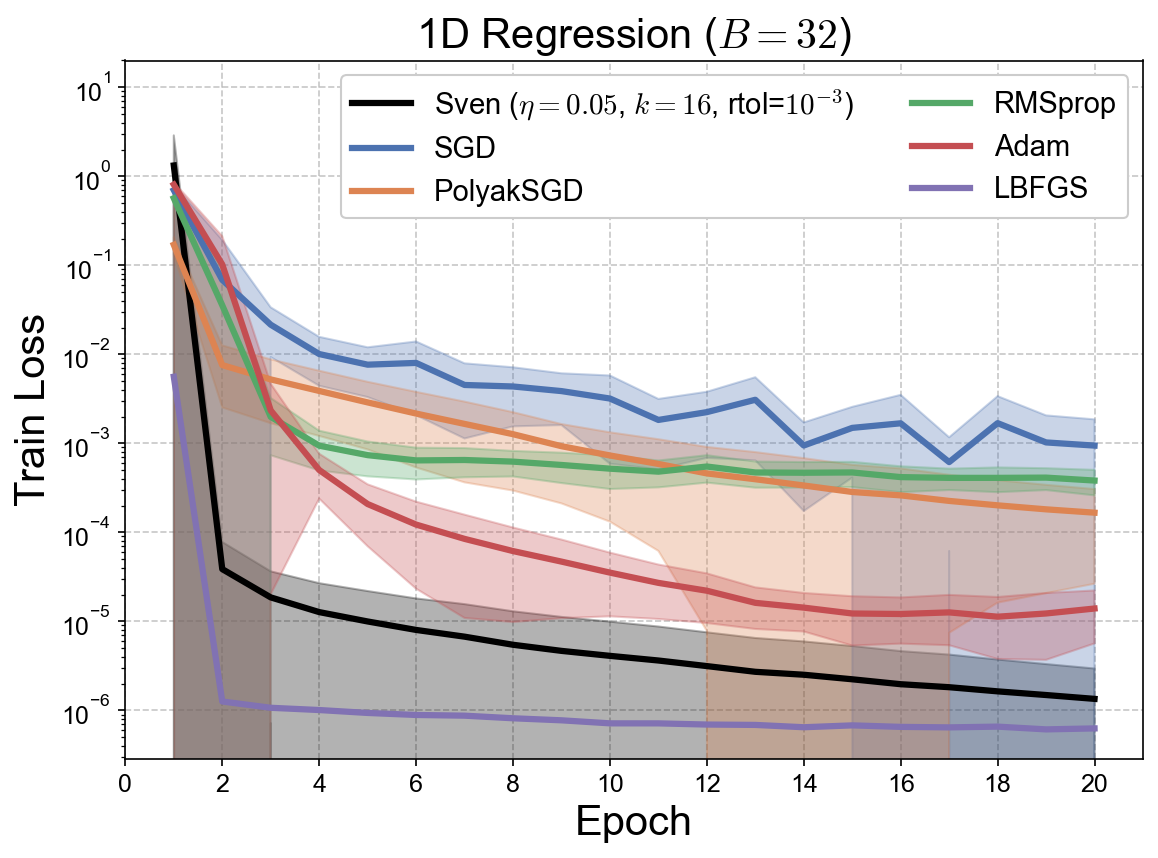

In [62]:
colors = sns.color_palette("deep")
fig, ax = plt.subplots(figsize=(8, 6))

best_svd_row = best_row(df_svd)
n_epochs = len(best_svd_row['train_loss_mean'])
epochs_train = np.arange(1, n_epochs + 1)
plt.plot(epochs_train, best_svd_row['train_loss_mean'], color='k', lw=3, zorder=3,
          label=f"Sven ($\\eta={best_svd_row['lr']}$, $k={int(best_svd_row['k'])}$, rtol=${lr_labels[best_svd_row['rtol']]}$)")
plt.fill_between(epochs_train,
                 best_svd_row['train_loss_mean'] - best_svd_row['train_loss_std'],
                 best_svd_row['train_loss_mean'] + best_svd_row['train_loss_std'],
                 color='k', alpha=0.3, zorder=2)

for i, opt in enumerate(['SGD', 'PolyakSGD', 'RMSprop', 'Adam', 'LBFGS']):
    sub = df_baseline[(df_baseline['optimizer'] == opt) & (df_baseline['batch_size'] == bs)]
    if len(sub) == 0:
        continue
    b = best_row(sub)
    plt.plot(epochs_train, b['train_loss_mean'], color=colors[i], lw=3, zorder=3, label=f"{opt}")
    plt.fill_between(epochs_train,
                     b['train_loss_mean'] - b['train_loss_std'],
                     b['train_loss_mean'] + b['train_loss_std'],
                     color=colors[i], alpha=0.3, zorder=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Train Loss')
ax.set_yscale('log')
plt.legend(ncol=2, loc='upper right', frameon=True, framealpha=1)
ax.set_title(f"1D Regression ($B = {bs}$)")
plt.ylim([None, 20])
plt.xlim(0, n_epochs + 1)
plt.xticks(np.arange(0, n_epochs + 1, max(1, n_epochs // 10)))
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'train_loss_best.pdf')
plt.show()

### Val loss, best of each optimizer

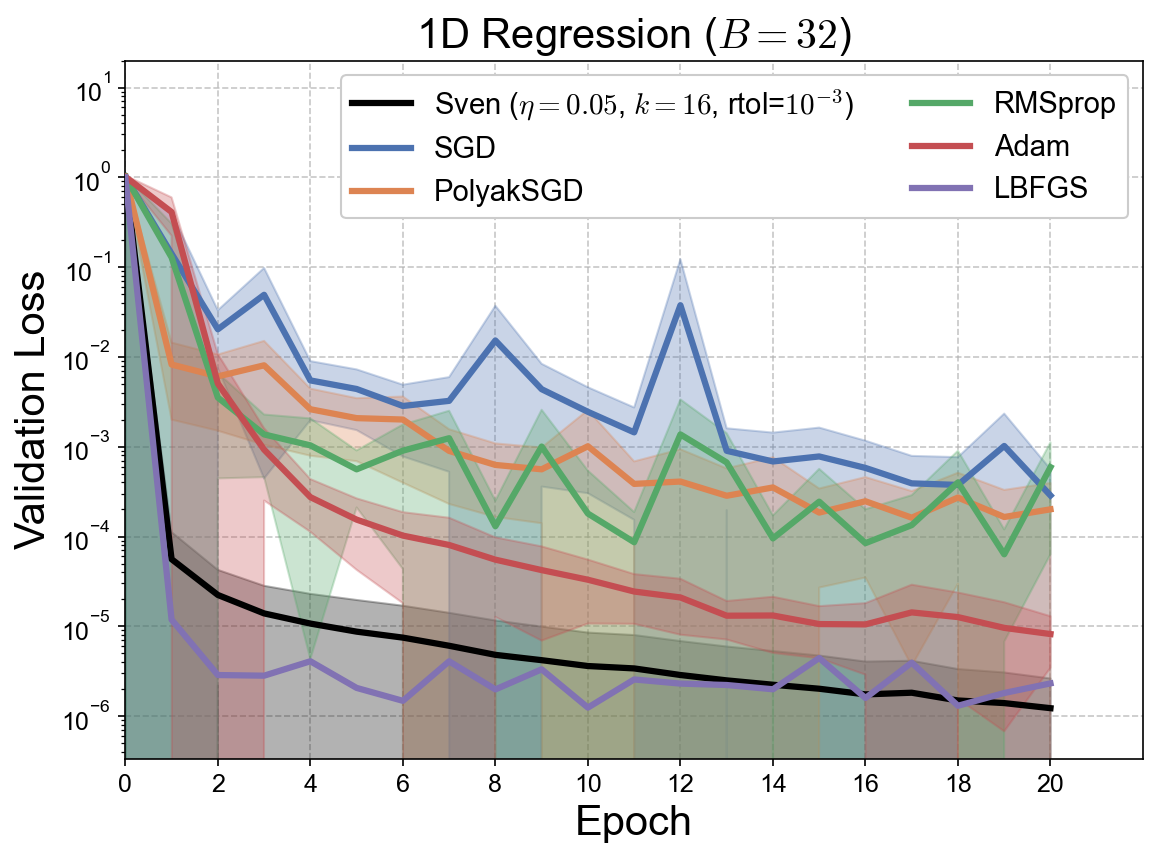

In [64]:
colors = sns.color_palette("deep")
fig, ax = plt.subplots(figsize=(8, 6))

best_svd_row = best_row(df_svd)
n_epochs = len(best_svd_row['val_loss_mean'])
epochs_train = np.arange(n_epochs)
plt.plot(epochs_train, best_svd_row['val_loss_mean'], color='k', lw=3, zorder=3,
          label=f"Sven ($\\eta={best_svd_row['lr']}$, $k={int(best_svd_row['k'])}$, rtol=${lr_labels[best_svd_row['rtol']]}$)")
plt.fill_between(epochs_train,
                 best_svd_row['val_loss_mean'] - best_svd_row['val_loss_std'],
                 best_svd_row['val_loss_mean'] + best_svd_row['val_loss_std'],
                 color='k', alpha=0.3, zorder=2)

for i, opt in enumerate(['SGD', 'PolyakSGD', 'RMSprop', 'Adam', 'LBFGS']):
    sub = df_baseline[(df_baseline['optimizer'] == opt) & (df_baseline['batch_size'] == bs)]
    if len(sub) == 0:
        continue
    b = best_row(sub)
    plt.plot(epochs_train, b['val_loss_mean'], color=colors[i], lw=3, zorder=3, label=f"{opt}")
    plt.fill_between(epochs_train,
                     b['val_loss_mean'] - b['val_loss_std'],
                     b['val_loss_mean'] + b['val_loss_std'],
                     color=colors[i], alpha=0.3, zorder=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_yscale('log')
plt.legend(ncol=2, loc='upper right', frameon=True, framealpha=1)
ax.set_title(f"1D Regression ($B = {bs}$)")
plt.ylim([None, 20])
plt.xlim(0, n_epochs + 1)
plt.xticks(np.arange(0, n_epochs + 1, max(1, n_epochs // 10)))
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'val_loss_best.pdf')
plt.show()

### Wall time vs train loss

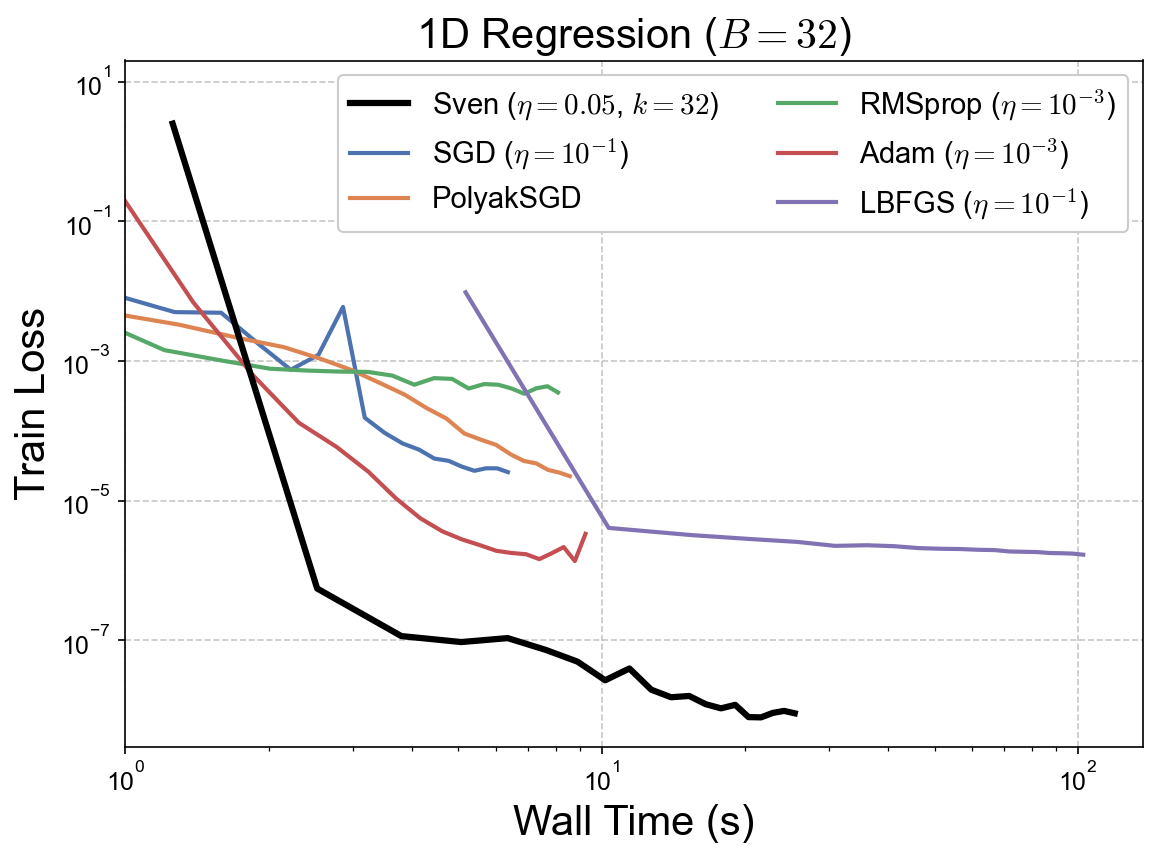

In [13]:
colors = sns.color_palette("deep")
fig, ax = plt.subplots(figsize=(8, 6))

best_svd_row = best_row(df_svd[df_svd['batch_size'] == bs])
train_mean, train_std = mean_std(best_svd_row, 'train')
et_mean, _ = mean_std(best_svd_row, 'epoch_times')
t = np.cumsum(et_mean[:len(train_mean)])
plot_band(ax, t, train_mean, train_std, color='k', lw=3, zorder=3,
          label=f"Sven ($\\eta={best_svd_row['lr']}$, $k={int(best_svd_row['k'])}$)")

for i, opt in enumerate(['SGD', 'PolyakSGD', 'RMSprop', 'Adam', 'LBFGS']):
    sub = df_baseline[(df_baseline['optimizer'] == opt) & (df_baseline['batch_size'] == bs)]
    if len(sub) == 0:
        continue
    b = best_row(sub)
    m, s = mean_std(b, 'train')
    et, _ = mean_std(b, 'epoch_times')
    tt = np.cumsum(et[:len(m)])
    lbl = f"{opt} ($\\eta={lr_labels[b['lr']]}$)" if opt != 'PolyakSGD' else opt
    plot_band(ax, tt, m, s, color=colors[i], lw=2, zorder=2, label=lbl)

ax.set_xlabel('Wall Time (s)')
ax.set_ylabel('Train Loss')
ax.set_yscale('log')
ax.set_xscale('log')
plt.legend(ncol=2, loc='upper right', frameon=True, framealpha=1)
ax.set_title(f"1D Regression ($B = {bs}$)")
plt.ylim([None, 20])
plt.xlim([1, None])
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'wall_time_vs_train_loss_best.pdf')
plt.show()

### Wall time vs val loss

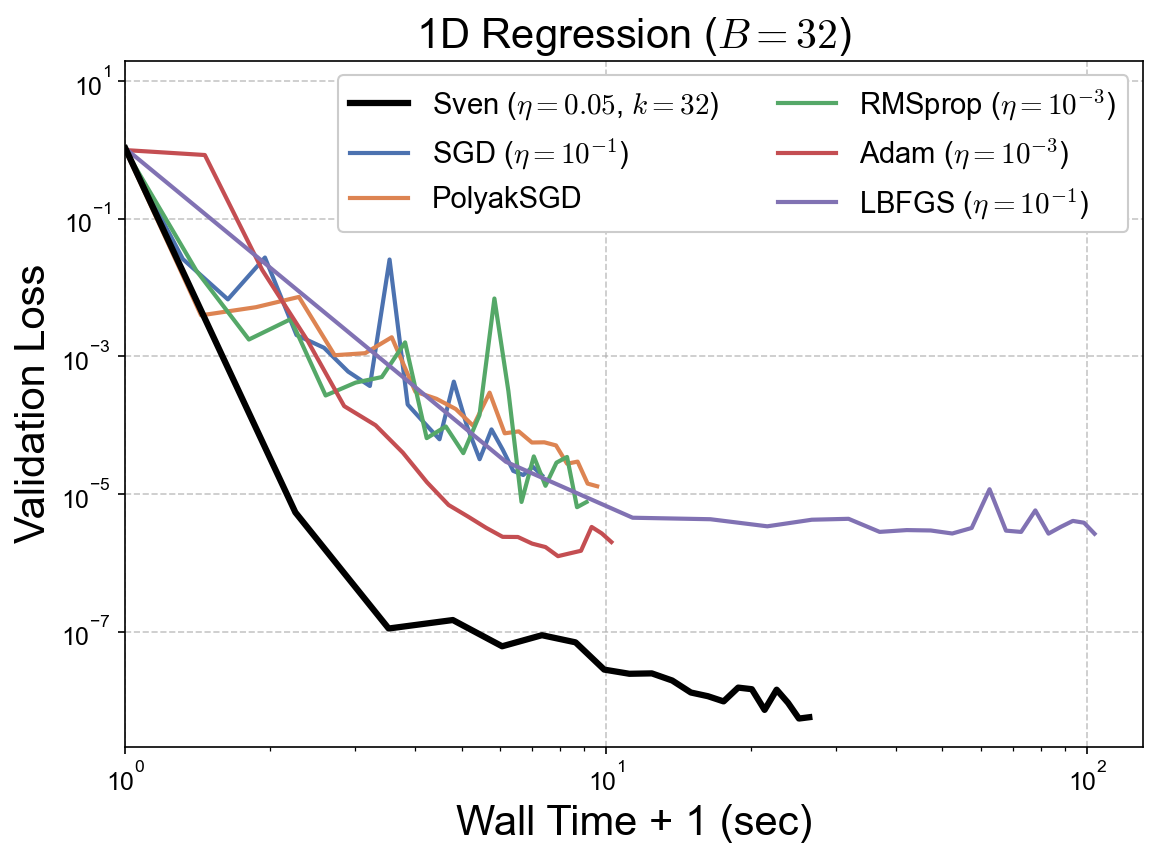

In [14]:
colors = sns.color_palette("deep")
fig, ax = plt.subplots(figsize=(8, 6))

best_svd_row = best_row(df_svd[df_svd['batch_size'] == bs])
val_mean, val_std = mean_std(best_svd_row, 'val')
et_mean, _ = mean_std(best_svd_row, 'epoch_times')
# val has one extra (epoch 0) entry relative to epoch_times; prepend a 1s offset like the original notebook
et_prepended = np.concatenate([[1.0], et_mean])
t = np.cumsum(et_prepended[:len(val_mean)])
plot_band(ax, t, val_mean, val_std, color='k', lw=3, zorder=3,
          label=f"Sven ($\\eta={best_svd_row['lr']}$, $k={int(best_svd_row['k'])}$)")

for i, opt in enumerate(['SGD', 'PolyakSGD', 'RMSprop', 'Adam', 'LBFGS']):
    sub = df_baseline[(df_baseline['optimizer'] == opt) & (df_baseline['batch_size'] == bs)]
    if len(sub) == 0:
        continue
    b = best_row(sub)
    m, s = mean_std(b, 'val')
    et, _ = mean_std(b, 'epoch_times')
    et = np.concatenate([[1.0], et])
    tt = np.cumsum(et[:len(m)])
    lbl = f"{opt} ($\\eta={lr_labels[b['lr']]}$)" if opt != 'PolyakSGD' else opt
    plot_band(ax, tt, m, s, color=colors[i], lw=2, zorder=2, label=lbl)

ax.set_xlabel('Wall Time + 1 (sec)')
ax.set_ylabel('Validation Loss')
ax.set_yscale('log')
ax.set_xscale('log')
plt.legend(ncol=2, loc='upper right', frameon=True, framealpha=1)
ax.set_title(f"1D Regression ($B = {bs}$)")
plt.ylim([None, 20])
plt.xlim([1, None])
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'wall_time_vs_val_loss_best.pdf')
plt.show()

### Overlay different $k$ values

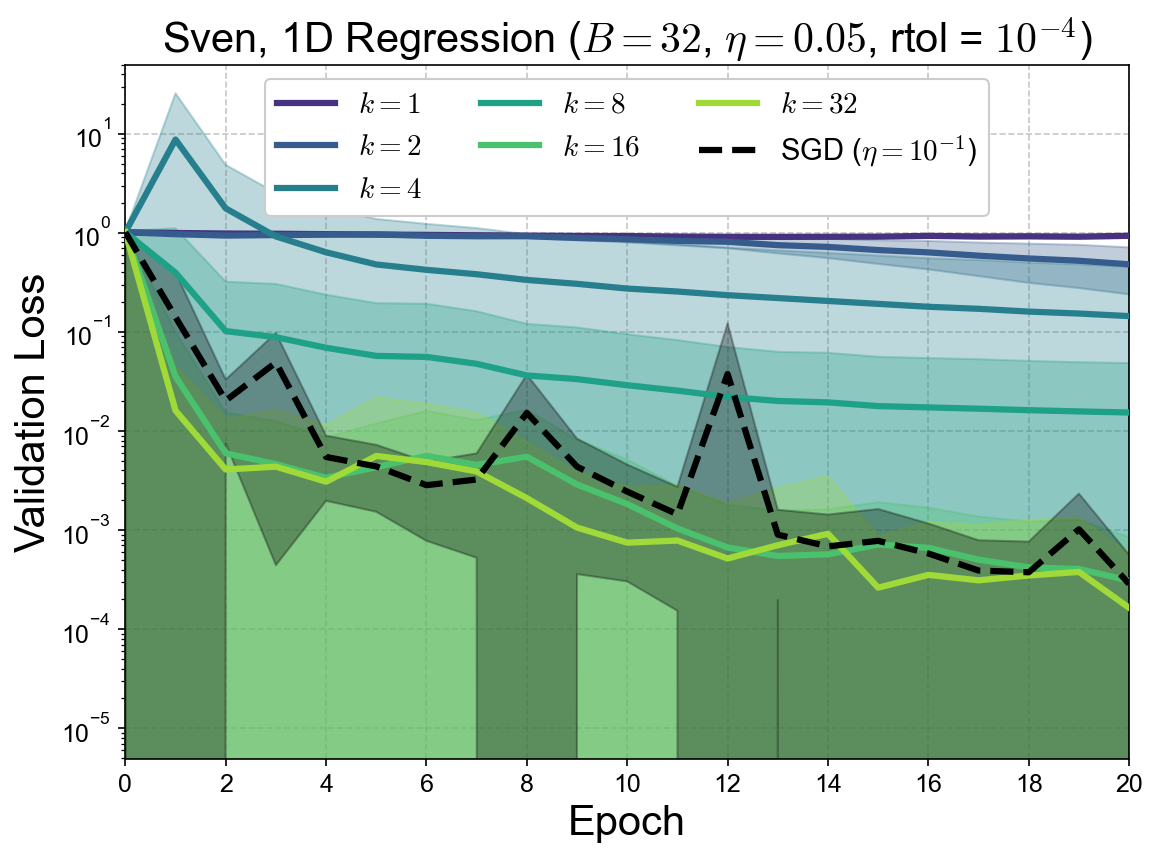

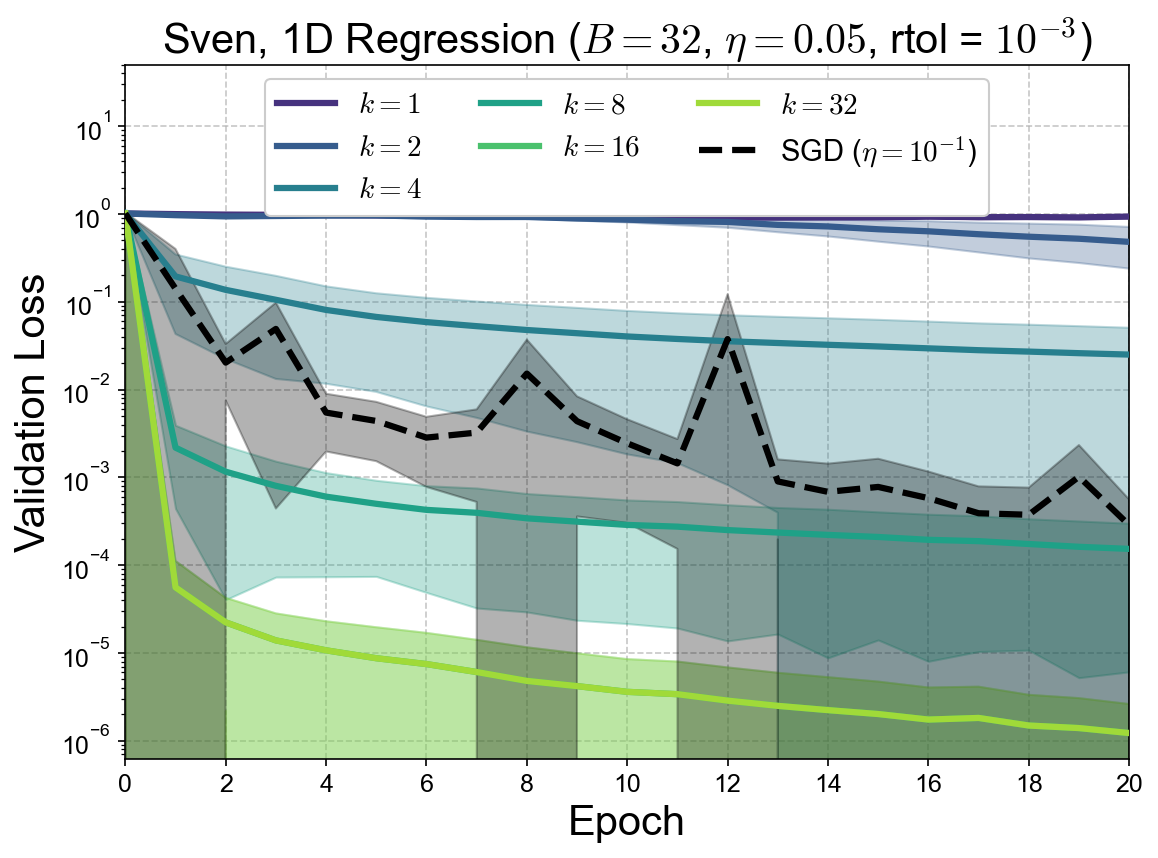

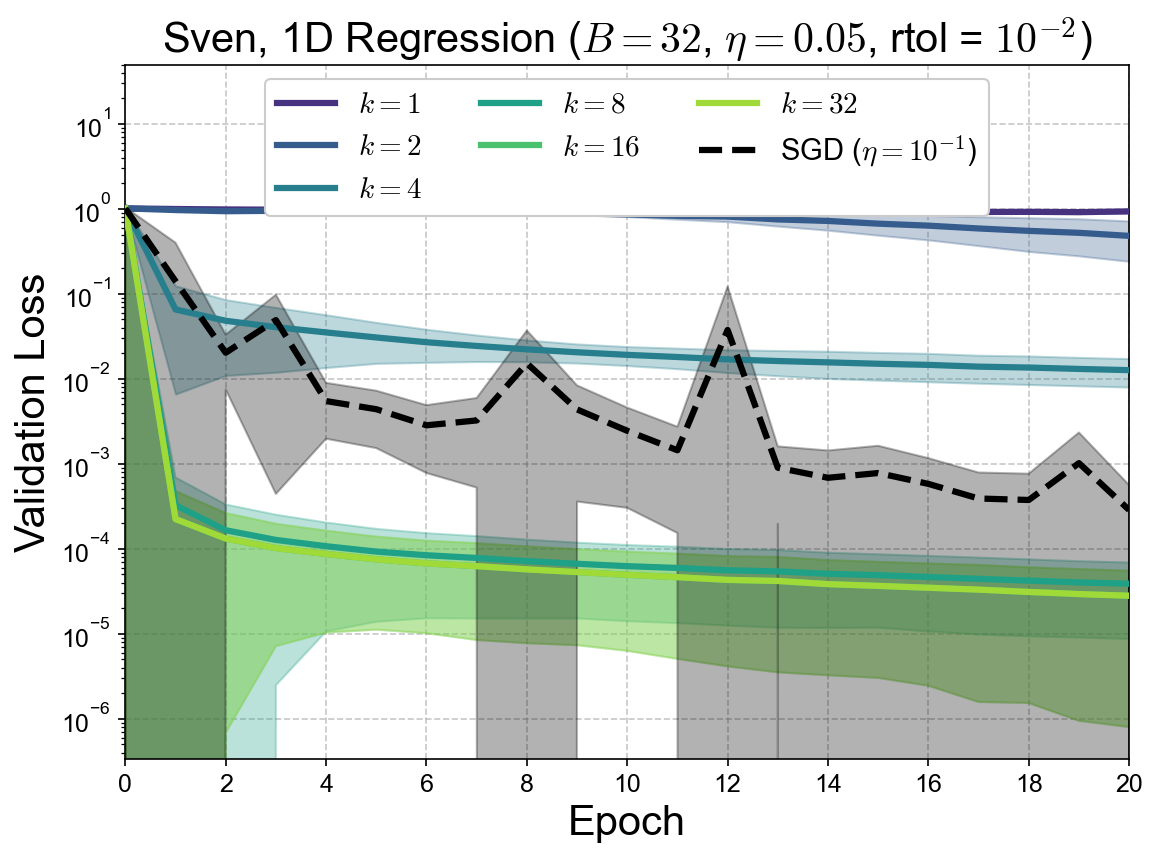

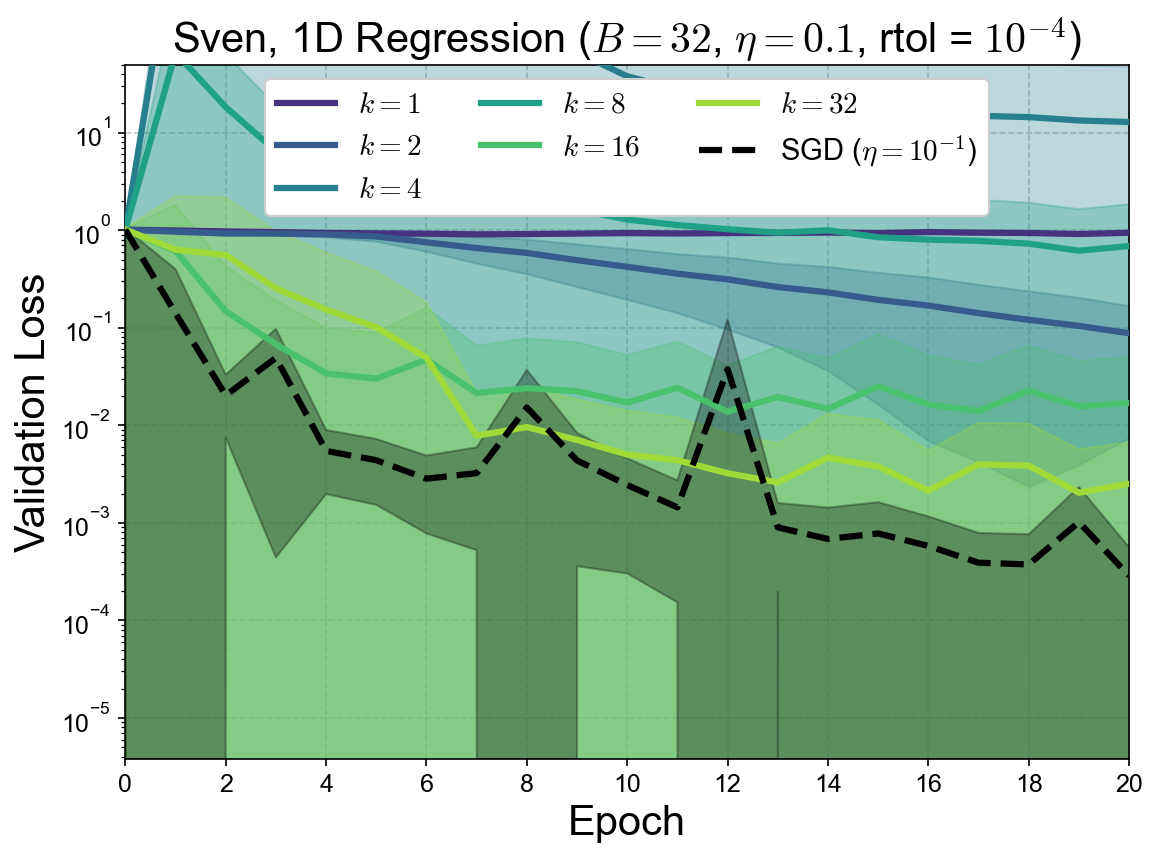

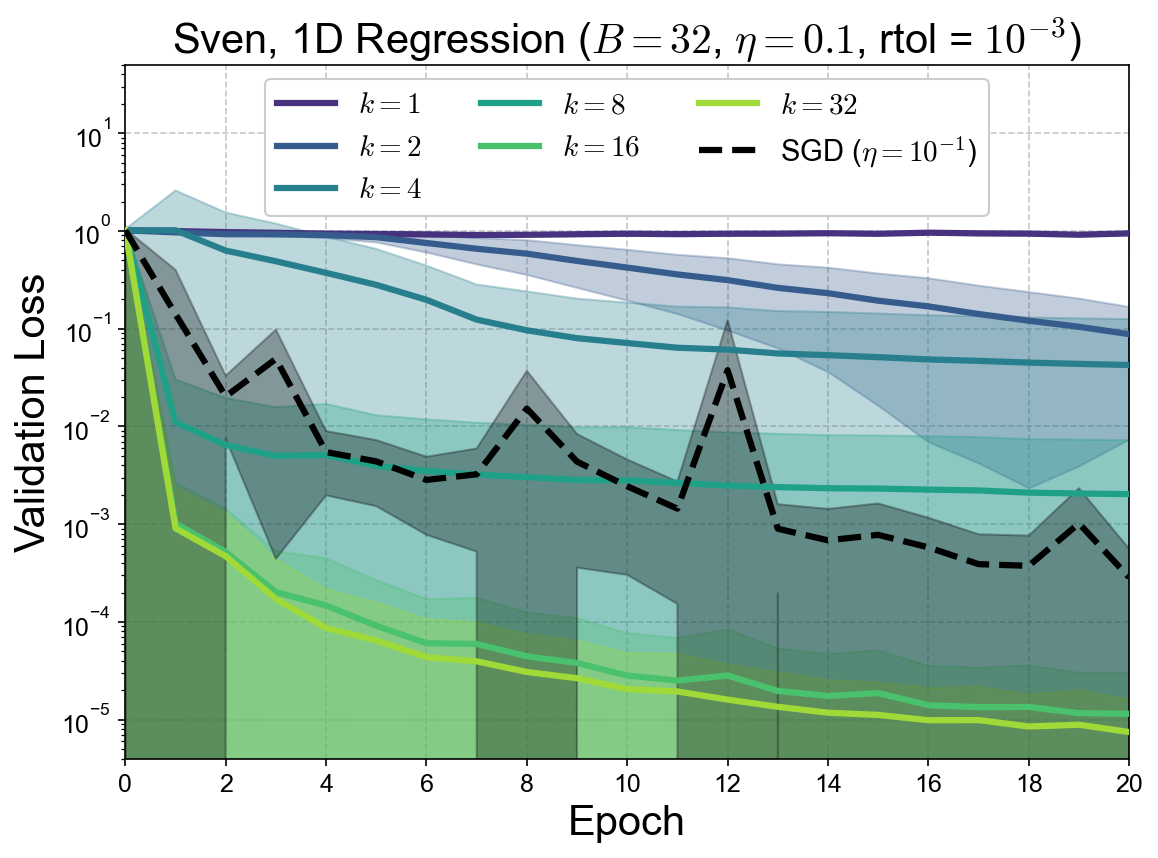

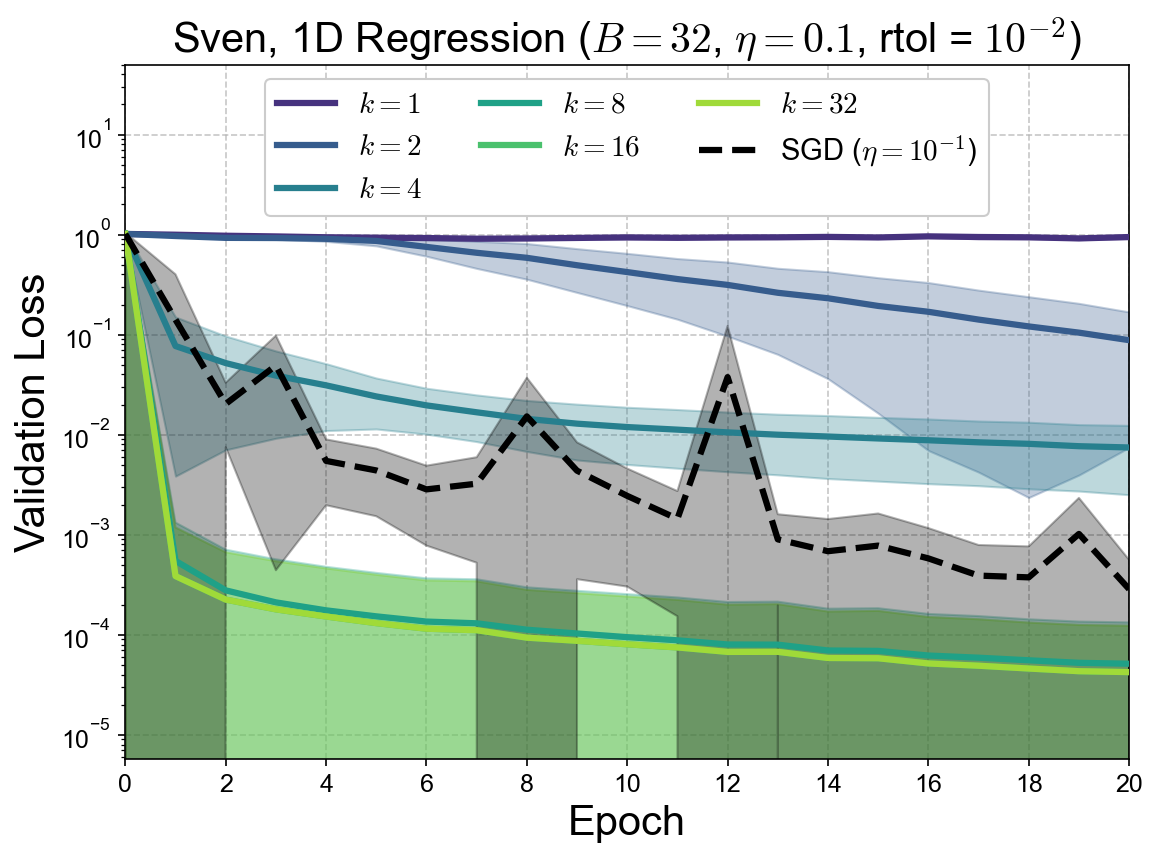

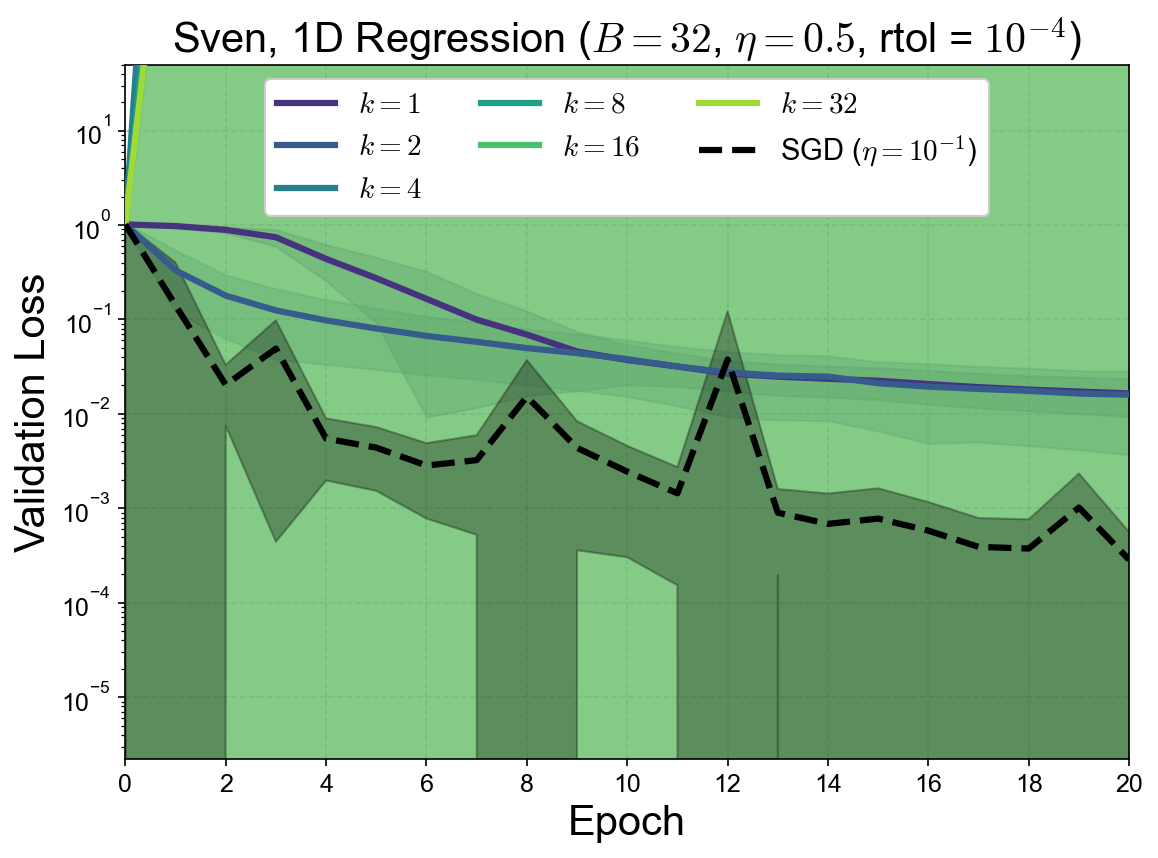

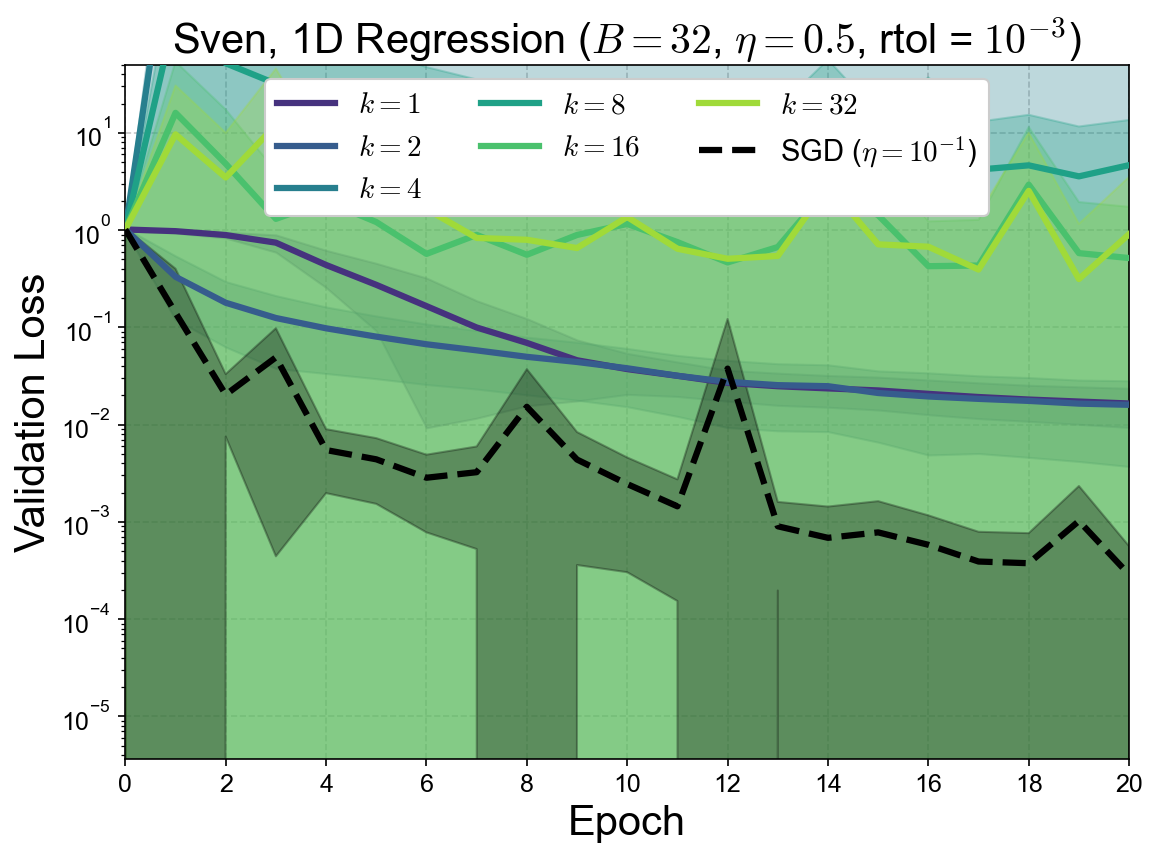

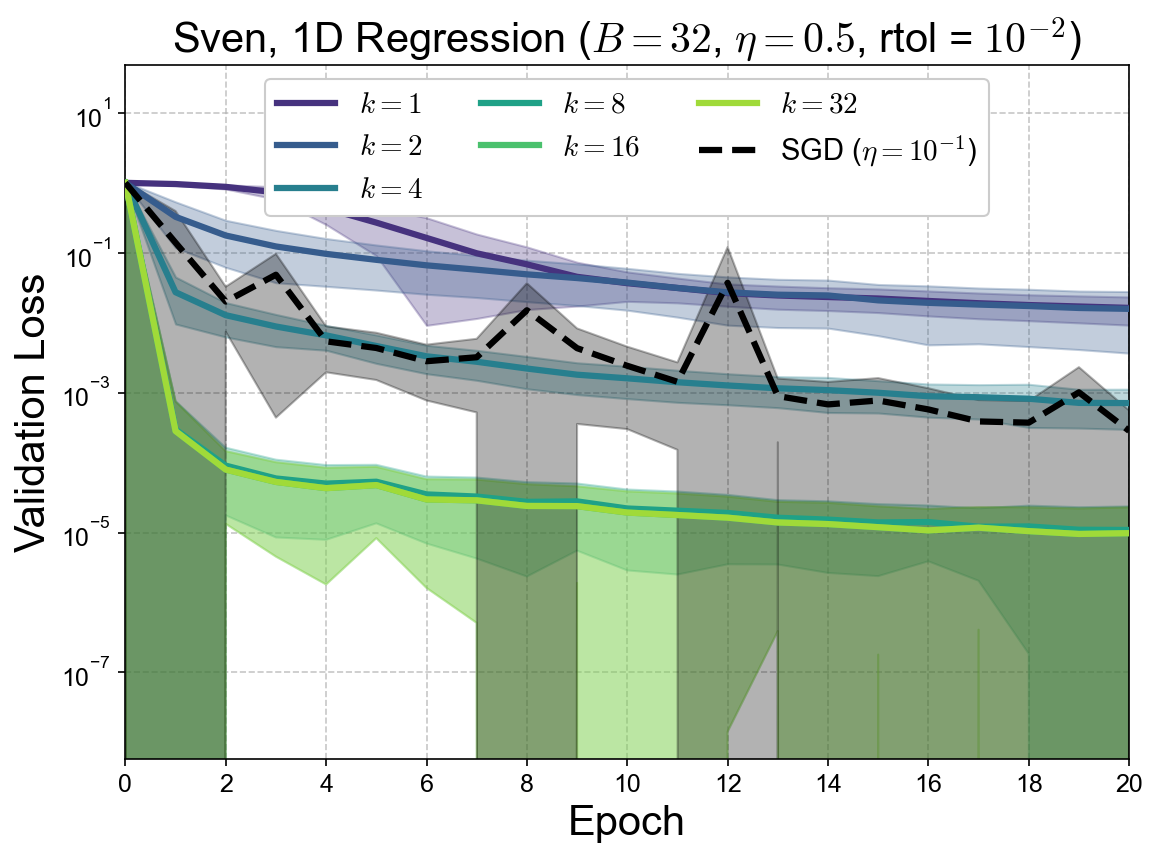

In [68]:
# Val loss overlay of k values, for each (lr, rtol).
for LR in [0.05, 0.1, 0.5]:
    for RTOL in [1e-4, 1e-3, 1e-2]:
        sel = df_svd[(df_svd['batch_size'] == bs) & (df_svd['lr'] == LR) & (df_svd['rtol'] == RTOL)]
        if len(sel) == 0:
            continue
        k_values = sorted(sel['k'].unique())
        k_colors = sns.color_palette('viridis', n_colors=len(k_values))
        fig, ax = plt.subplots(figsize=(8, 6))

        n_val = None
        for i, k in enumerate(k_values):
            row = sel[sel['k'] == k].iloc[0]
            if n_val is None:
                n_val = len(m)
            epochs = np.arange(len(row['val_loss_mean']))
            plt.plot(epochs, row['val_loss_mean'], color=k_colors[i], lw=3, zorder=3, label=f"$k={int(k)}$")
            plt.fill_between(epochs,
                             row['val_loss_mean'] - row['val_loss_std'],
                             row['val_loss_mean'] + row['val_loss_std'],
                             color=k_colors[i], alpha=0.3, zorder=2)

        df_sgd = df_baseline[(df_baseline['batch_size'] == bs) & (df_baseline['optimizer'] == 'SGD')]
        if len(df_sgd) > 0:
            b = best_row(df_sgd)
            epochs = np.arange(len(b['val_loss_mean']))
            plt.plot(epochs, b['val_loss_mean'], color='k', lw=3, zorder=3, ls='--',
                     label=f"SGD ($\\eta={lr_labels[b['lr']]}$)")
            plt.fill_between(epochs,
                             b['val_loss_mean'] - b['val_loss_std'],
                             b['val_loss_mean'] + b['val_loss_std'],
                             color='k', alpha=0.3, zorder=2)

        ax.set_xlabel('Epoch')
        ax.set_ylabel('Validation Loss')
        ax.set_yscale('log')
        plt.legend(ncol=3, loc='upper center', frameon=True, framealpha=1)
        ax.set_title(f"Sven, 1D Regression ($B = {bs}$, $\\eta={LR}$, rtol = ${lr_labels[RTOL]}$)")
        plt.ylim([None, 50])
        plt.xlim(0, (n_val or 0))
        plt.xticks(np.arange(0, (n_val or 0) + 1, max(1, (n_val or 10) // 10)))
        plt.grid(axis='both', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.savefig(PLOT_DIR / f"val_loss_k_comparison_bs{bs}_lr{LR}_rtol{RTOL}.pdf")
        plt.show()